<a href="https://colab.research.google.com/github/Zinc-zn/MachineLearning2026/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# JS06 - Klasifikasi 2: Lab 2 (SVM dengan Data Dummy Non-Linier)

Pada praktikum ke-2 ini, kita akan mencoba memanfaatkan SVM untuk mengklasifikasikan data dengan distribusi non-linier. Dengan menggunakan *kernel trick*, SVM mampu membuat decision boundaries pada data non-linier.


## Langkah 1 - Ilustrasi Data Non-Linier

Data yang terpisah secara tidak linier menjadi masalah bagi SVM linier. Kernel menjadi kebutuhan bagi SVM untuk melakukan fitting pada hubungan non-linier dengan sebuah classifier linier.

### Langkah 1a - Import Library

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

### Langkah 1b - Buat Kembali Fungsi Plotting

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

### Langkah 1c - Buat Data Dummy Non-Linier

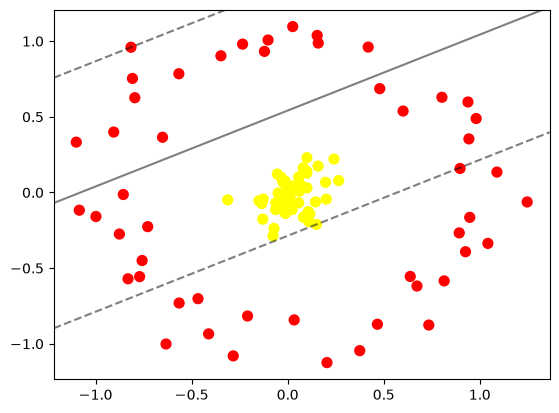

In [3]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

Berdasarkan contoh data di atas, **tidak ditemukan garis pemisah linier** yang mampu memisahkan data. Oleh karena itu, diperlukan proyeksi (sudut pandang) lain terhadap data supaya data dapat terpisahkan dengan jelas. Pada kegiatan ini, proyeksi yang digunakan adalah **proyeksi berbasis radial**.

$$
r = np.exp(-(X**2).sum(1))
$$

In [4]:
r = np.exp(-(X**2).sum(1))

Karena proyeksi radial tidak cukup menggunakan model 2D, plot visualisasi diubah menjadi model 3D.

In [5]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20, 10], azip=(-180, 180),
         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[ 0.15811877,  0.17462977],
       [ 0.08101324,  0.16258092],
       [ 0.06161204,  0.00789534],
       [-0.02269396, -0.09223527],
       [-0.20896545, -0.81640121],
       [ 0.94781648, -0.16453896],
       [ 0.08264567, -0.16267894],
       [ 0.11552714, -0.14028906],
       [-0.00496595, -0.0864617 ],
       [ 0.14999317, -0.21092861],
       [-0.06239333, -0.11317504],
       [-0.10207495,  1.00772414],
       [-0.63325404, -1.00132267],
       [ 0.20449835, -1.12423201],
       [-0.04981498, -0.00334408],
       [ 0.00421171, -0.02752056],
       [ 0.01649707, -0.00586948],
       [ 0.9433259 ,  0.35404653],
       [-0.00415563,  0.02789206],
       [-0.81568951,  0.95976161],
       [ 0.60074645,  0.53815649],
       [-0.14967133, -0.05475251],
       [ 0.20070448, -0.04404045],
       [-0.99809769, -0.15872285],
       [ 1.08912346,  0.13472702],
       [ 0.4191504 ,  0.96093203],
       [ 0.73472962, -0.8760829 ],
       [

Output widget interaktif hanya terlihat saat notebook dijalankan secara interaktif. Berikut tampilan statis pada sudut pandang $elev=30$, $azim=30$ untuk ilustrasi:

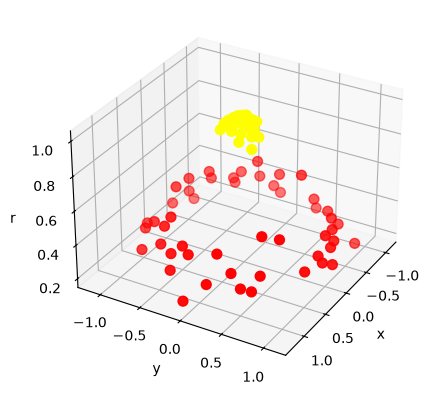

In [6]:
ax = plt.subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
ax.view_init(elev=30, azim=30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('r')
plt.show()

Pada proyeksi 3D berbasis radius $r$, kedua kelas terpisahkan sempurna oleh sebuah bidang datar ($r = \text{konstanta}$) - inilah ide *kernel trick*: proyeksi implisit ke dimensi lebih tinggi.

## Langkah 2 - Fitting Model

Walaupun data dapat ditampilkan secara terpisah, proyeksi titik data sejumlah N ke dalam suatu dimensi N menyebabkan beban komputasi bertambah. Untuk mengatasi hal ini, kernel **radial basis function (RBF)** pada scikit-learn digunakan.

In [7]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000000.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Plot hasil decision boundaries dari kernel RBF.

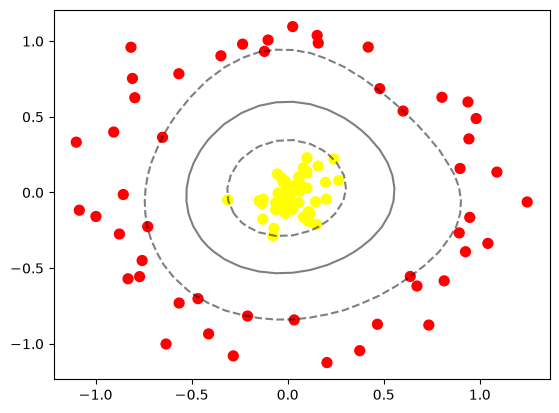

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none')

**Kesimpulan Lab 2:** Dengan kernel RBF, SVM mampu menghasilkan decision boundary non-linier berbentuk lingkaran yang memisahkan kedua kelas data circles dengan sempurna - tanpa harus menghitung proyeksi eksplisit ke dimensi tinggi.